# **Cleaning**

In [ ]:
# import needed libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#read the data

data= pd.read_csv('/content/movielens_merged.csv')
data.head(10)

,userId,movieId,title,genres,rating,timestamp,tags,imdbId,tmdbId
0,1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,4.0,964982703,pixar|fun,114709,862.0
1,1,3,Grumpier Old Men (1995),Comedy|Romance,4.0,964981247,moldy|old,113228,15602.0
2,1,6,Heat (1995),Action|Crime|Thriller,4.0,964982224,NaN,113277,949.0
3,1,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,5.0,964983815,mystery|twist ending|serial killer,114369,807.0
4,1,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,5.0,964982931,mindfuck|suspense|thriller|tricky|twist ending...,114814,629.0
5,1,70,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller,3.0,964982400,NaN,116367,755.0
6,1,101,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance,5.0,964980868,crime|off-beat comedy|quirky,115734,13685.0
7,1,110,Braveheart (1995),Action|Drama|War,4.0,964982176,beautiful scenery|epic|historical|inspirationa...,112573,197.0
8,1,151,Rob Roy (1995),Action|Drama|Romance|War,5.0,964984041,NaN,114287,11780.0
9,1,157,Canadian Bacon (1995),Comedy|War,5.0,964984100,NaN,109370,1775.0


In [ ]:
#get data information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   title      100836 non-null  object 
 3   genres     100836 non-null  object 
 4   rating     100836 non-null  float64
 5   timestamp  100836 non-null  int64  
 6   tags       48287 non-null   object 
 7   imdbId     100836 non-null  int64  
 8   tmdbId     100823 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 6.9+ MB


In [ ]:
# check the number of null values

data.isnull().sum()

,0
userId,0
movieId,0
title,0
genres,0
rating,0
timestamp,0
tags,52549
imdbId,0
tmdbId,13


In [ ]:
#check the percentage of the messing values

missing_prc= data.isnull().mean()*100
print(missing_prc)

userId        0.000000
movieId       0.000000
title         0.000000
genres        0.000000
rating        0.000000
timestamp     0.000000
tags         52.113333
imdbId        0.000000
tmdbId        0.012892
dtype: float64


In [ ]:
# check duplicated rows

data.duplicated().sum()

np.int64(0)

In [ ]:
# 1. Drop 'tags': not needed (52.1%)
data= data.drop(['tags'], axis=1)
data.head()

,userId,movieId,title,genres,rating,timestamp,imdbId,tmdbId
0,1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,4.0,964982703,114709,862.0
1,1,3,Grumpier Old Men (1995),Comedy|Romance,4.0,964981247,113228,15602.0
2,1,6,Heat (1995),Action|Crime|Thriller,4.0,964982224,113277,949.0
3,1,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,5.0,964983815,114369,807.0
4,1,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,5.0,964982931,114814,629.0


In [ ]:
# 2. Drop missing rows for 'tmdbId'
data= data.dropna(subset=['tmdbId']).copy()

In [ ]:
# 3. Clipping for rating (in case we have rating>5, we clip it to 5)
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower, upper=upper)

In [ ]:
# 4. Drop the 'title' column because each movie has a unique ID already so we don't need to keep the title
data= data.drop(['title'], axis=1)

In [ ]:
# 5. Clean genres
data['genres'] = data['genres'].str.split('|')

In [ ]:
data.head()

,userId,movieId,genres,rating,timestamp,imdbId,tmdbId
0,1,1,"[Adventure, Animation, Children, Comedy, Fantasy]",4.0,964982703,114709,862.0
1,1,3,"[Comedy, Romance]",4.0,964981247,113228,15602.0
2,1,6,"[Action, Crime, Thriller]",4.0,964982224,113277,949.0
3,1,47,"[Mystery, Thriller]",5.0,964983815,114369,807.0
4,1,50,"[Crime, Mystery, Thriller]",5.0,964982931,114814,629.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100823 entries, 0 to 100835
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100823 non-null  int64  
 1   movieId    100823 non-null  int64  
 2   genres     100823 non-null  object 
 3   rating     100823 non-null  float64
 4   timestamp  100823 non-null  int64  
 5   imdbId     100823 non-null  int64  
 6   tmdbId     100823 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 6.2+ MB


In [ ]:
# 6. Multi_Hot encoding because genre contains more than one value
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(
    mlb.fit_transform(data['genres']),
    columns=mlb.classes_,
    index=data.index
)

# combine the new columns with data and delete the old one
data = pd.concat([data.drop(columns=['genres']), genres_encoded], axis=1)

In [ ]:
data.head()

,userId,movieId,rating,timestamp,imdbId,tmdbId,(no genres listed),Action,Adventure,Animation,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,1,4.0,964982703,114709,862.0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,3,4.0,964981247,113228,15602.0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1,6,4.0,964982224,113277,949.0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1,47,5.0,964983815,114369,807.0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,1,50,5.0,964982931,114814,629.0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100823 entries, 0 to 100835
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   userId              100823 non-null  int64  
 1   movieId             100823 non-null  int64  
 2   rating              100823 non-null  float64
 3   timestamp           100823 non-null  int64  
 4   imdbId              100823 non-null  int64  
 5   tmdbId              100823 non-null  float64
 6   (no genres listed)  100823 non-null  int64  
 7   Action              100823 non-null  int64  
 8   Adventure           100823 non-null  int64  
 9   Animation           100823 non-null  int64  
 10  Children            100823 non-null  int64  
 11  Comedy              100823 non-null  int64  
 12  Crime               100823 non-null  int64  
 13  Documentary         100823 non-null  int64  
 14  Drama               100823 non-null  int64  
 15  Fantasy             100823 non-null  in

In [ ]:
# Useful features
# Calculate the mean of rating for both users and movies
data['user_mean_rating'] = data.groupby('userId')['rating'].transform('mean')
data['movie_mean_rating'] = data.groupby('movieId')['rating'].transform('mean')

# Calculate the difference of rating
data['rating_diff'] = data['movie_mean_rating'] - data['user_mean_rating']


In [ ]:
# Save Data
data.to_csv('Cleaned_Data.csv', index=False)

# **Visualization**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/Cleaned_Data.csv')

df.head()

,userId,movieId,rating,timestamp,imdbId,tmdbId,(no genres listed),Action,Adventure,Animation,...,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,user_mean_rating,movie_mean_rating,rating_diff
0,1,1,4.0,964982703,114709,862.0,0,0,1,1,...,0,0,0,0,0,0,0,4.366379,3.920930,-0.445449
1,1,3,4.0,964981247,113228,15602.0,0,0,0,0,...,0,0,1,0,0,0,0,4.366379,3.259615,-1.106764
2,1,6,4.0,964982224,113277,949.0,0,1,0,0,...,0,0,0,0,1,0,0,4.366379,3.946078,-0.420301
3,1,47,5.0,964983815,114369,807.0,0,0,0,0,...,0,1,0,0,1,0,0,4.366379,3.975369,-0.391010
4,1,50,5.0,964982931,114814,629.0,0,0,0,0,...,0,1,0,0,1,0,0,4.366379,4.237745,-0.128634


In [ ]:
df.shape

(100823, 29)

In [ ]:
df.columns

Index(['userId', 'movieId', 'rating', 'timestamp', 'imdbId', 'tmdbId',
       '(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western', 'user_mean_rating', 'movie_mean_rating',
       'rating_diff'],
      dtype='object')

Distribution of Ratings

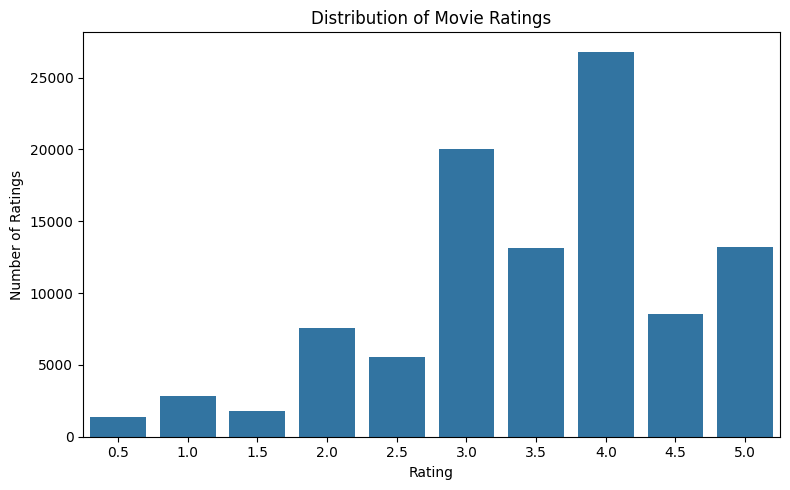

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='rating'
)

plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

Distribution of Ratings per User

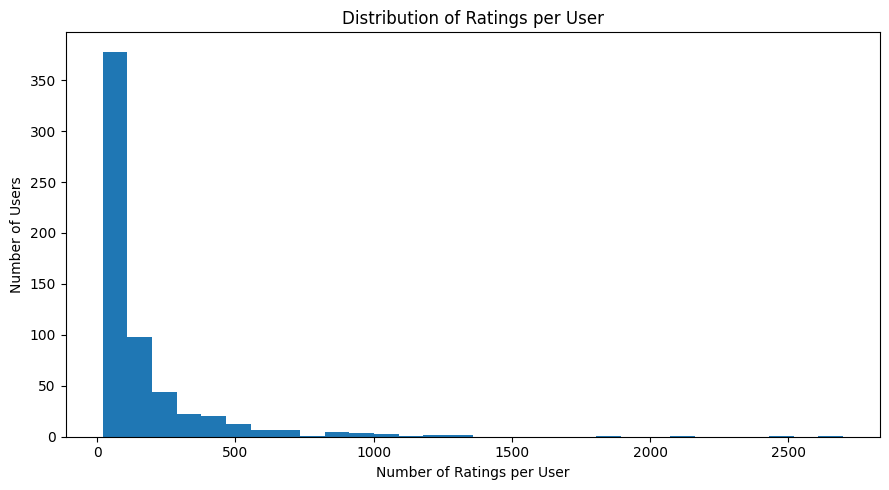

In [ ]:
ratings_per_user = df.groupby('userId').size()

plt.figure(figsize=(9, 5))

plt.hist(
    ratings_per_user,
    bins=30
)

plt.title('Distribution of Ratings per User')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

Distribution of Ratings per Movie

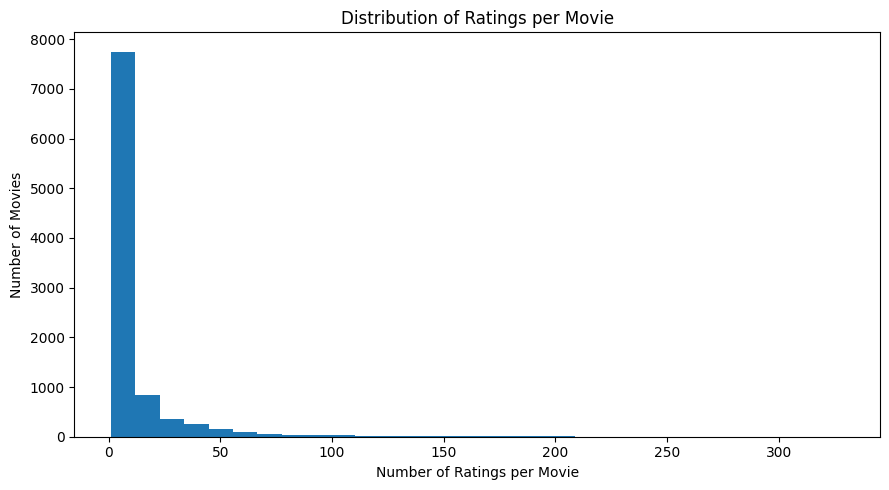

In [ ]:
ratings_per_movie = df.groupby('movieId').size()

plt.figure(figsize=(9, 5))

plt.hist(
    ratings_per_movie,
    bins=30
)

plt.title('Distribution of Ratings per Movie')
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Number of Movies')

plt.tight_layout()
plt.show()

Distribution of Average Ratings per User

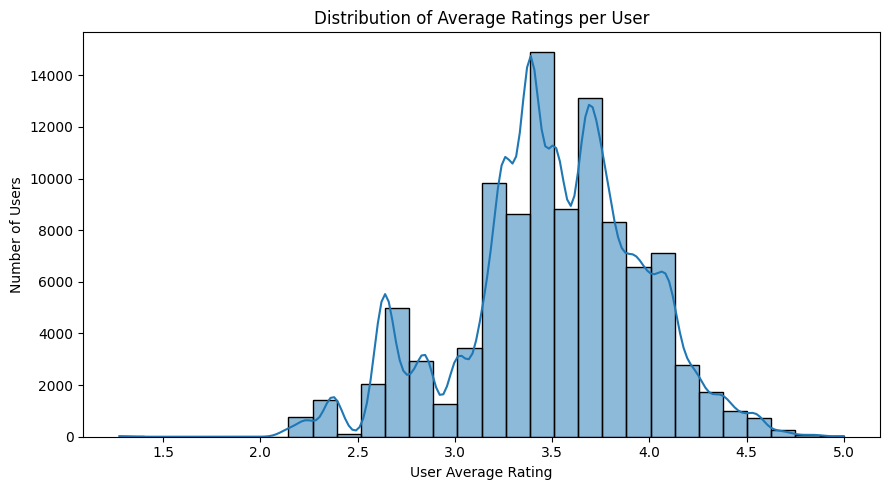

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df['user_mean_rating'],
    bins=30,
    kde=True
)

plt.title('Distribution of Average Ratings per User')
plt.xlabel('User Average Rating')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

Number of Ratings by Genre

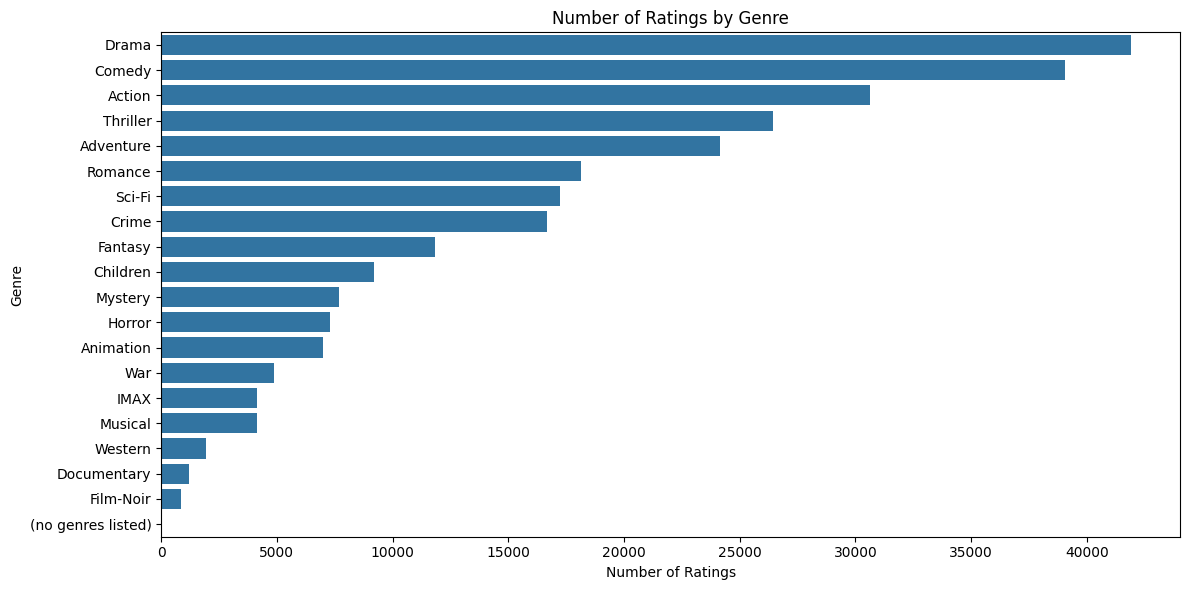

In [ ]:

genre_cols = [
    '(no genres listed)', 'Action', 'Adventure', 'Animation',
    'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
    'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical',
    'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]


genre_rating_counts = df[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=genre_rating_counts.values,
    y=genre_rating_counts.index
)

plt.title('Number of Ratings by Genre')
plt.xlabel('Number of Ratings')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

Average Rating by Genre

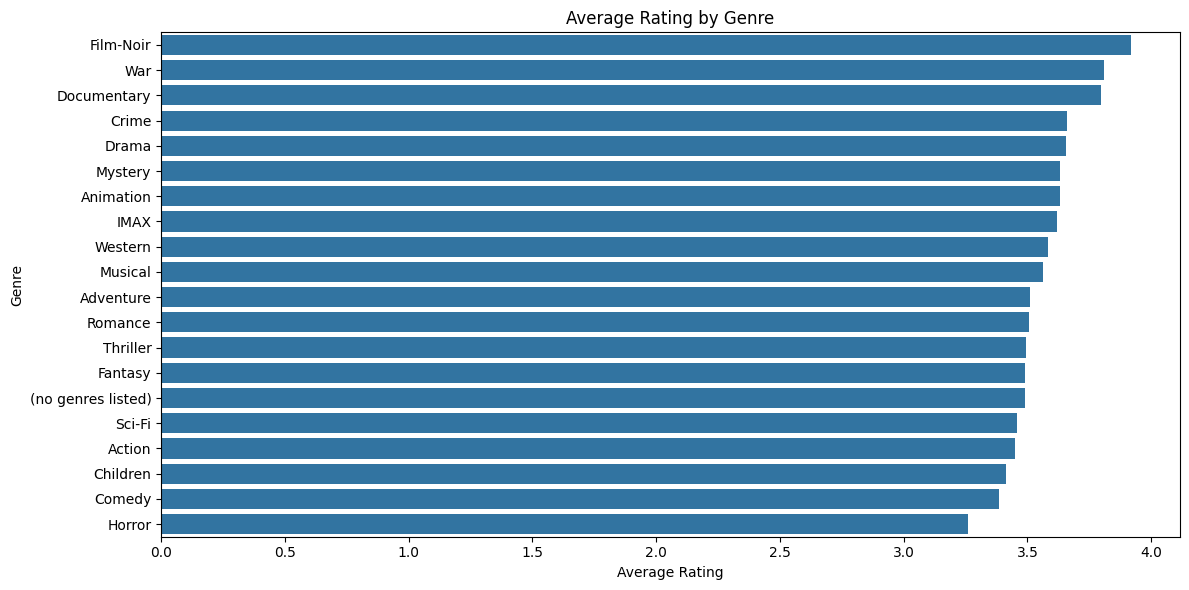

In [ ]:
genre_avg_rating = {}

for genre in genre_cols:
    genre_data = df[df[genre] == 1]
    genre_avg_rating[genre] = genre_data['rating'].mean()

genre_avg_rating = pd.Series(genre_avg_rating).sort_values(ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=genre_avg_rating.values,
    y=genre_avg_rating.index
)

plt.title('Average Rating by Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

Movie of Ratings vs Average Movie Rating

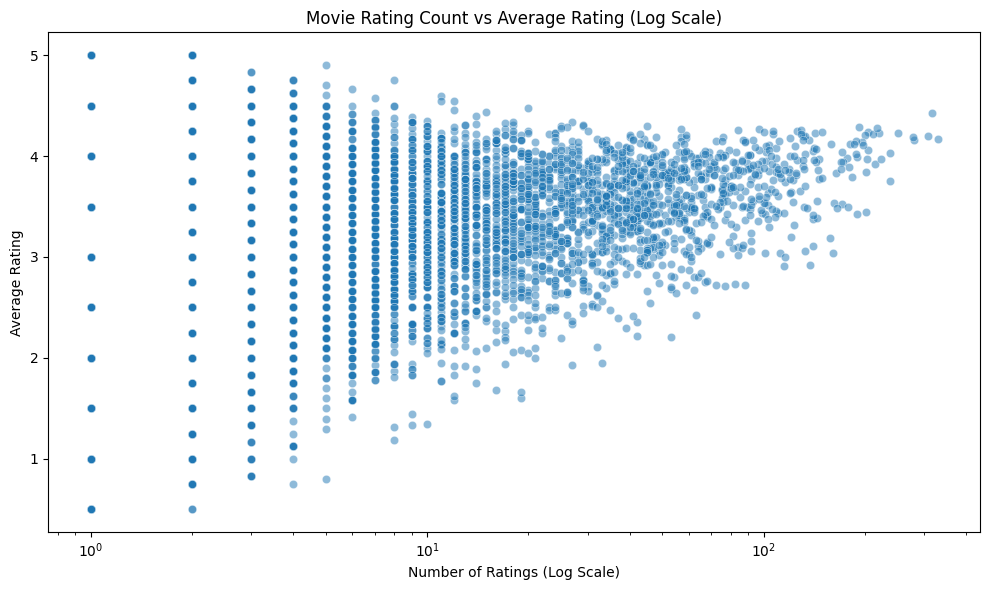

In [ ]:
movie_stats = df.groupby('movieId')['rating'].agg(
    rating_count='count',
    average_rating='mean'
).reset_index()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=movie_stats,
    x='rating_count',
    y='average_rating',
    alpha=0.5
)

plt.xscale('log')

plt.title('Movie Rating Count vs Average Rating (Log Scale)')
plt.xlabel('Number of Ratings (Log Scale)')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

User Average Rating Distribution

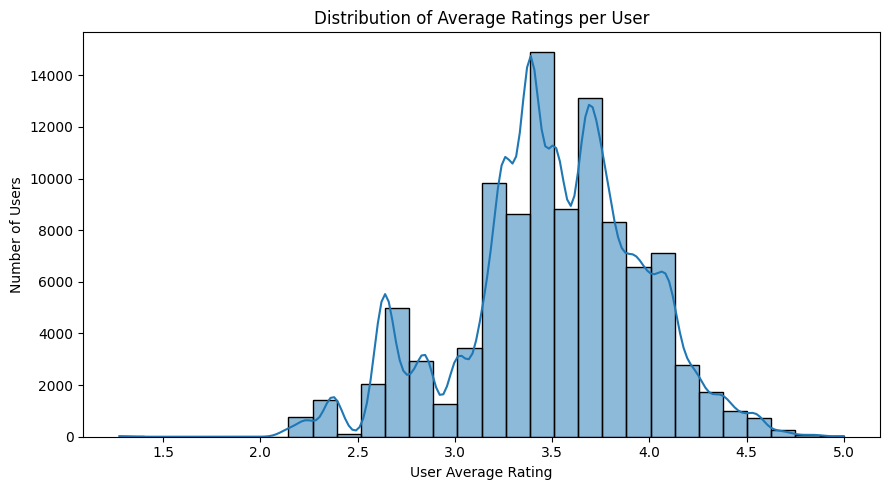

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df['user_mean_rating'],
    bins=30,
    kde=True
)

plt.title('Distribution of Average Ratings per User')
plt.xlabel('User Average Rating')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

User Rating vs Movie Average Rating

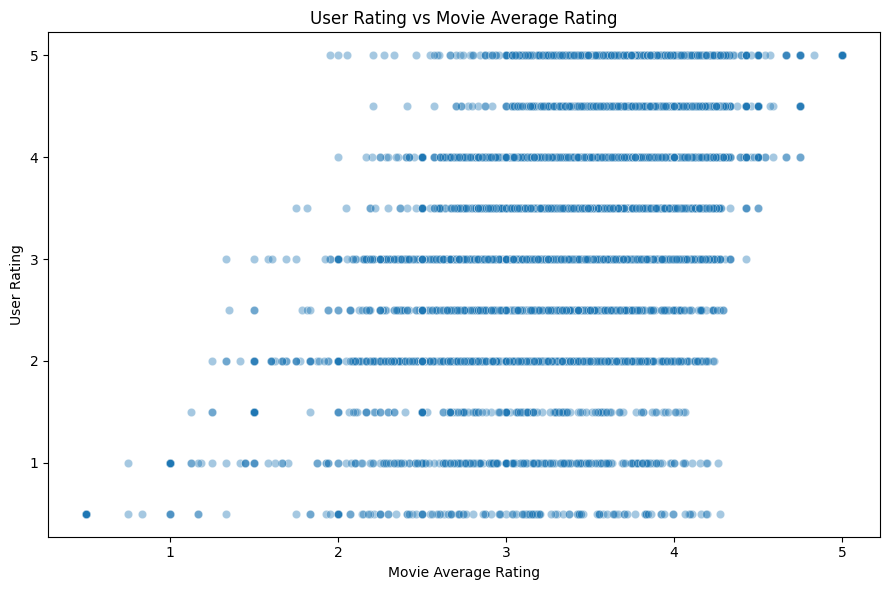

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x='movie_mean_rating',
    y='rating',
    alpha=0.4
)

plt.title('User Rating vs Movie Average Rating')
plt.xlabel('Movie Average Rating')
plt.ylabel('User Rating')

plt.tight_layout()
plt.show()

Rating Difference

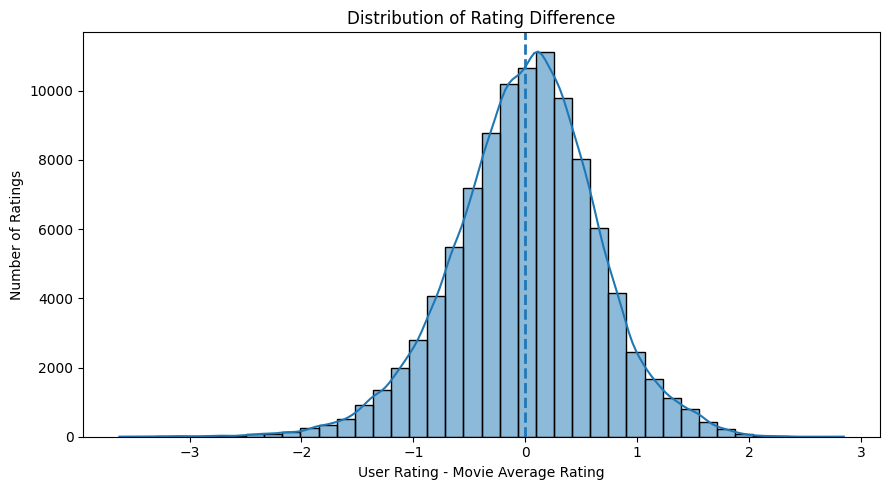

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df['rating_diff'],
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=2
)

plt.title('Distribution of Rating Difference')
plt.xlabel('User Rating - Movie Average Rating')
plt.ylabel('Number of Ratings')

plt.tight_layout()
plt.show()

Most Rated Movies

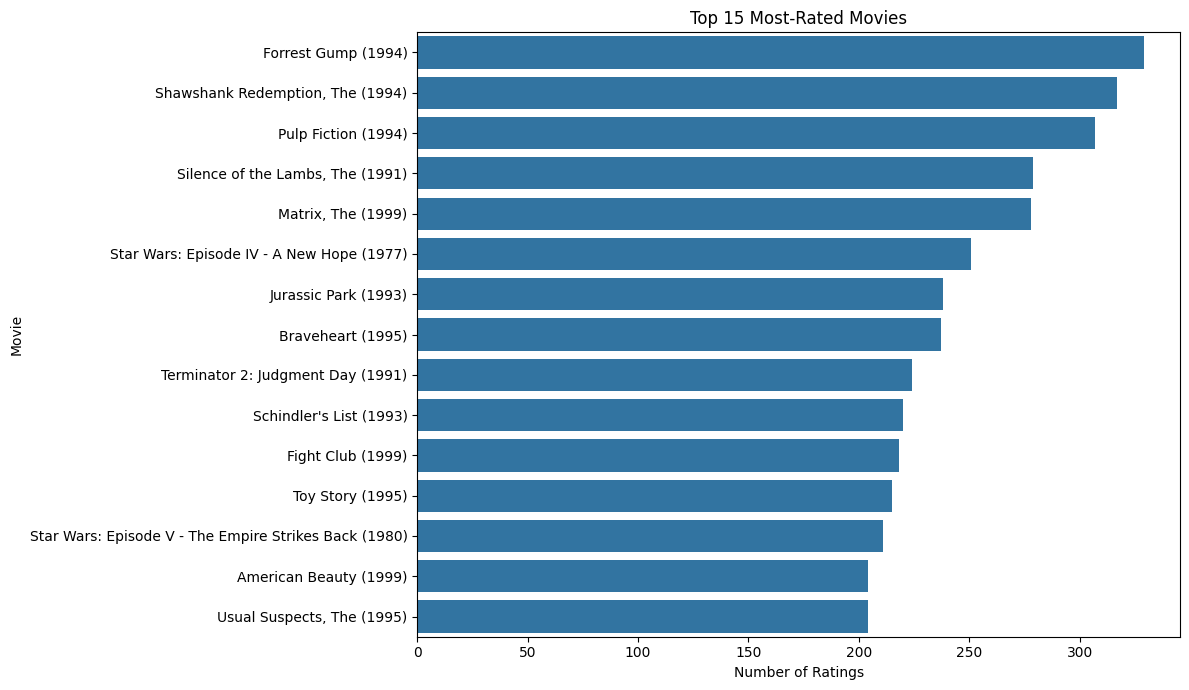

In [ ]:
# Load movie titles
movies = pd.read_csv('/content/movies.csv')


movie_stats = df.groupby('movieId').agg(
    rating_count=('rating', 'count'),
    average_rating=('rating', 'mean')
).reset_index()


movie_stats = movie_stats.merge(
    movies[['movieId', 'title']],
    on='movieId',
    how='left'
)

# Top 15 most-rated movies
top_movies = movie_stats.sort_values(
    'rating_count',
    ascending=False
).head(15)


plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_movies,
    x='rating_count',
    y='title'
)

plt.title('Top 15 Most-Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie')

plt.tight_layout()
plt.show()

User–Movie Interaction Sparsity

In [ ]:
# Create User-Movie interaction matrix
user_movie_matrix = df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

# Calculate sparsity
total_cells = user_movie_matrix.shape[0] * user_movie_matrix.shape[1]
observed_ratings = user_movie_matrix.notna().sum().sum()

sparsity = 1 - (observed_ratings / total_cells)

print(f"Users: {user_movie_matrix.shape[0]:,}")
print(f"Movies: {user_movie_matrix.shape[1]:,}")
print(f"Observed Ratings: {observed_ratings:,}")
print(f"Sparsity: {sparsity:.2%}")

Users: 610
Movies: 9,716
Observed Ratings: 100,823
Sparsity: 98.30%


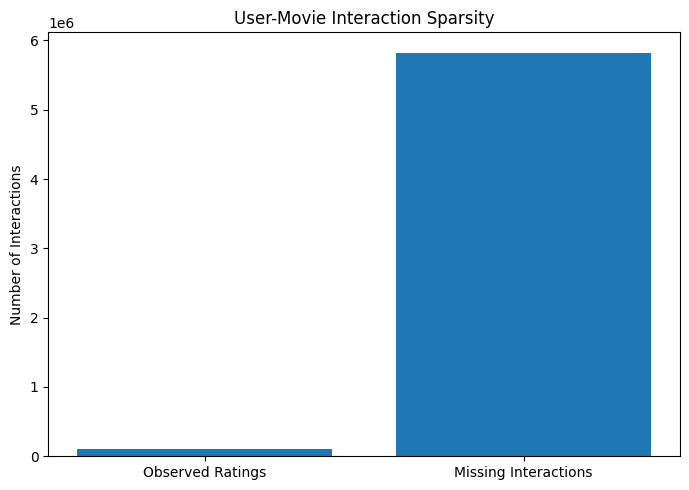

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    ['Observed Ratings', 'Missing Interactions'],
    [observed_ratings, total_cells - observed_ratings]
)

plt.title('User-Movie Interaction Sparsity')
plt.ylabel('Number of Interactions')

plt.tight_layout()
plt.show()

Genre Co-occurrence Heatmap

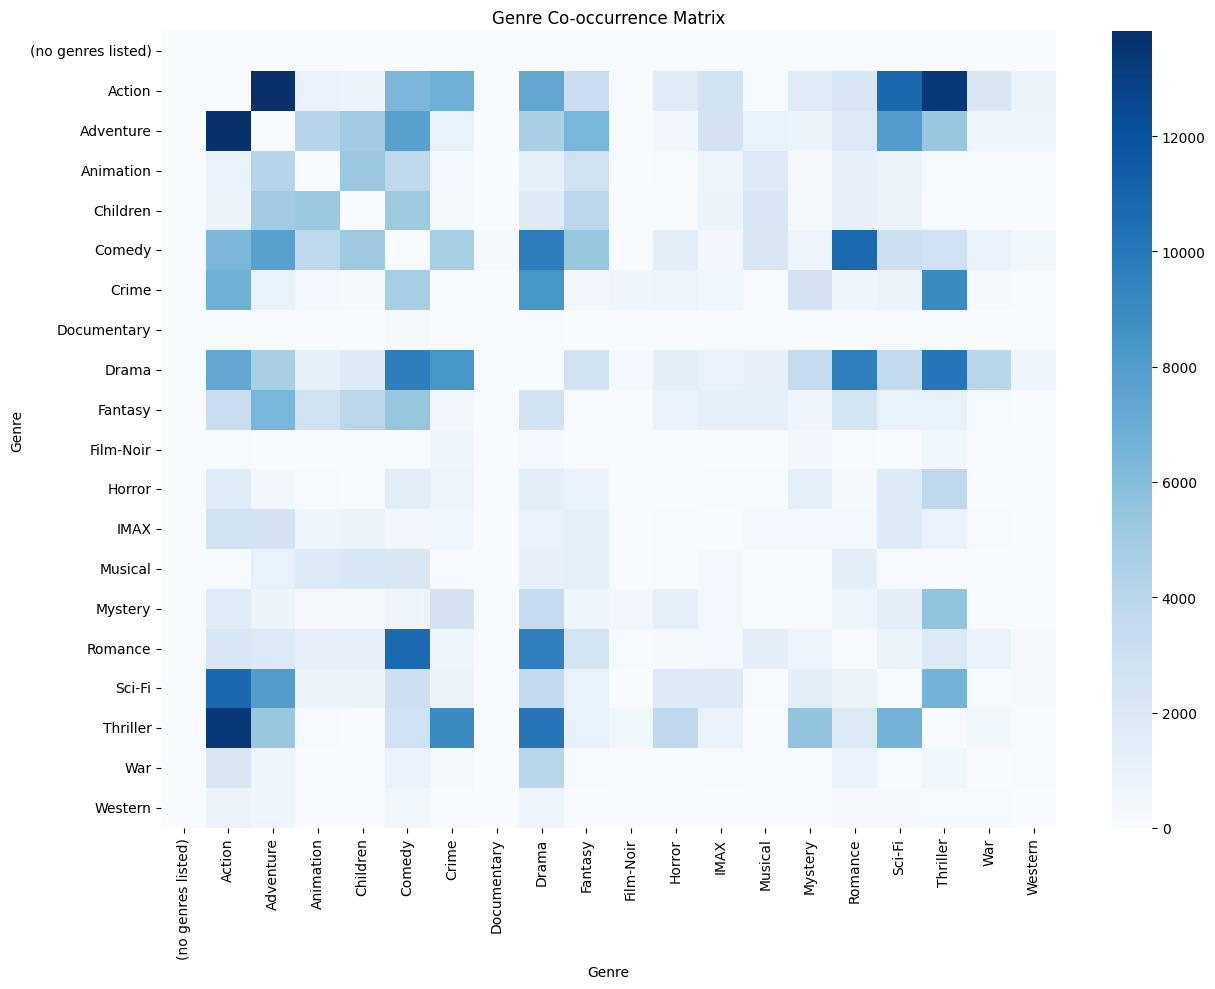

In [ ]:
# Genre co-occurrence matrix
genre_matrix = df[genre_cols].T.dot(df[genre_cols])

# Remove self-co-occurrence
for genre in genre_matrix.index:
    genre_matrix.loc[genre, genre] = 0

plt.figure(figsize=(13, 10))

sns.heatmap(
    genre_matrix,
    cmap='Blues'
)

plt.title('Genre Co-occurrence Matrix')
plt.xlabel('Genre')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

# **Machine Learning:**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

X = data.drop(columns=['rating', 'timestamp'])
y = data['rating']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (100823, 27)
Target shape: (100823,)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (80658, 27)
X_test shape: (20165, 27)


In [ ]:



rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)



RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:

y_pred = rf_model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("--- Model Evaluation Results ---")
print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Random Forest MAE:  {mae:.4f}")

--- Model Evaluation Results ---
Random Forest RMSE: 0.8064
Random Forest MAE:  0.6098
